In [1]:
# ============================================================
# IMPORTS
# ============================================================
from MLEvaluator import MLEvaluator
from XAIEvaluator import XAIEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('outputs', exist_ok=True)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')


# LIME — import direct sans try/except
from lime.lime_tabular import LimeTabularExplainer
LIME_AVAILABLE = True
print('✓ LIME disponible')

✓ LIME disponible


In [5]:
evaluator = MLEvaluator.load("evaluator.pkl")

Evaluator chargé depuis 'evaluator.pkl'
   Modèles disponibles : ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']


In [21]:

# ============================================================
# CLASSE LIME
# ============================================================
class LIMEEvaluator(XAIEvaluator):
    """
    Génère et évalue des explications LIME pour les modèles
    entraînés dans MLEvaluator.

    Utilisation :
        evaluator = MLEvaluator.load('evaluator.pkl')
        lime_eval = LIMEEvaluator(evaluator)
        lime_eval.run()
    """


    def __init__(self, evaluator):
        """
        Initialise le LIMEEvaluator à partir d'un MLEvaluator déjà entraîné.
        Hérite de XAIEvaluator : sélection des instances, modèles retenus,
        attributs communs (X_train, X_test, feature_names...).
    
        Args:
            evaluator : instance de MLEvaluator chargée via .load()
        """
        super().__init__(evaluator)  
        self.explainer       = None
        self.mc_lime_results = {}
        self.lime_explanations  = {}  
        self.export_rows     = []
        self.evaluation_results = pd.DataFrame()

  
    # ── BLOC 2 : Création de l'explainer ──────────────────────
    def create_explainer(self):
        """
        Crée un LimeTabularExplainer unique partagé entre tous les modèles.
        Utilise les données d'entraînement comme référence pour générer
        les perturbations locales autour de chaque instance à expliquer.
        """
        from lime.lime_tabular import LimeTabularExplainer
        self.explainer = LimeTabularExplainer(
            self.X_train.values,
            feature_names=self.feature_names,
            class_names=self.CLASS_NAMES,
            mode='classification',
            discretize_continuous=False,
            random_state=42,
        )
        print('✓ LimeTabularExplainer créé')
   

    # ── BLOC 3 : Génération des explications ──────────────────
    def generate_explanations(self):
        """
        Génère les explications LIME pour chaque modèle retenu et chaque
        instance sélectionnée. Pour chaque instance, LIME perturbe les
        features et ajuste un modèle linéaire local pour estimer la
        contribution de chaque variable à la prédiction.
        Seules les instances correctement prédites sont expliquées.
        """
        print('\n GÉNÉRATION DES EXPLICATIONS LIME')
        print('=' * 50)
    
        for model_name, model in self.trained_models.items():
            if model_name not in self.SELECTED_MODELS:
                print(f'  {model_name} → ignoré (hors sélection)')
                continue
            if not hasattr(model, 'predict_proba'):
                print(f'  {model_name} → ignoré (pas de predict_proba)')
                continue
    
            print(f'\n  {model_name}...')
            model_explanations = []

            for class_name, sample_indices in self.selected_samples.items():
                for sample_idx in sample_indices:
                    try:
                        instance = self.X_test.iloc[sample_idx].values

                        predicted  = int(model.predict([instance])[0])
                        true_label = int(self.y_test.iloc[sample_idx])
                        if predicted != true_label:
                            print(f'    ⚠️ {model_name} se trompe sur instance {sample_idx} → ignorée')
                            continue
                        exp = self.explainer.explain_instance(
                            instance, model.predict_proba,
                            num_features=min(10, len(self.feature_names)),
                        )
                        model_explanations.append({
                            'instance_id'          : sample_idx,
                            'class_name'           : class_name,
                            'true_label'           : int(self.y_test.iloc[sample_idx]),
                            'predicted_label'      : int(model.predict([instance])[0]),
                            'prediction_proba'     : model.predict_proba([instance])[0].tolist(),
                            'feature_contributions': exp.as_list(),
                            'instance_values'      : self.X_test.iloc[sample_idx].to_dict(),
                        })
                    except Exception as e:
                        print(f'    Échec sample {sample_idx} : {e}')

            self.lime_explanations[model_name] = model_explanations
            print(f'    → {len(model_explanations)} explications ✓')

    # ── BLOC 4 : Visualisation ────────────────────────────────
    def plot_explanations(self):
        """
        Affiche les contributions des features pour chaque instance
        et chaque modèle, groupées par profil étudiant.
        - Barres vertes : contribution positive vers le profil prédit
        - Barres rouges : contribution négative (frein à la prédiction)
        Les graphiques sont sauvegardés dans outputs/.
        """
        print('\n VISUALISATION')
        for model_name, explanations in self.lime_explanations.items():
            if not explanations:
                continue
            by_class = {}
            for exp in explanations:
                by_class.setdefault(exp['class_name'], []).append(exp)

            for class_name, class_exps in by_class.items():
                n = len(class_exps)
                fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
                if n == 1:
                    axes = [axes]
                fig.suptitle(f'LIME — {model_name} — Profil {class_name}',
                             fontsize=14, fontweight='bold')

                for idx, exp_data in enumerate(class_exps):
                    ax = axes[idx]
                    features, contribs = zip(*exp_data['feature_contributions'])
                    bar_colors = ['#D85A30' if c < 0 else '#1D9E75' for c in contribs]
                    y_pos = np.arange(len(features))
                    bars = ax.barh(y_pos, contribs, color=bar_colors, alpha=0.8)
                    ax.set_yticks(y_pos)
                    ax.set_yticklabels(
                        [f[:35] + '...' if len(f) > 35 else f for f in features], fontsize=8)
                    mn, mx = min(contribs), max(contribs)
                    pad = (mx - mn) * 0.2 if mx != mn else 0.005
                    ax.set_xlim(mn - pad, mx + pad)
                    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
                    ax.set_title(
                        f'Instance {exp_data["instance_id"]} — '
                        f'Vrai : {self.CLASS_NAMES[exp_data["true_label"]]} | '
                        f'Prédit : {self.CLASS_NAMES[exp_data["predicted_label"]]}',
                        fontsize=10)
                    ax.grid(axis='x', alpha=0.3)
                    for bar, val in zip(bars, contribs):
                        w = bar.get_width()
                        offset = 0.02 * max(abs(w), 0.001)
                        ax.text(w + offset if w >= 0 else w - offset,
                                bar.get_y() + bar.get_height() / 2,
                                f'{val:.4f}', ha='left' if w >= 0 else 'right',
                                va='center', fontsize=7)

                plt.tight_layout()
                plt.savefig(f'outputs/lime_{model_name}_{class_name}.png',
                            dpi=150, bbox_inches='tight')
                plt.show()

    # ── BLOC 5 : Métriques de qualité ─────────────────────────
    def _local_fidelity(self, model, instance, n_samples=200):
        """
        Calcule la fidélité locale d'une explication LIME.
        Mesure la corrélation de Pearson entre les prédictions
        du modèle original et celles du modèle linéaire local de LIME
        sur un voisinage perturbé autour de l'instance.
        Valeur proche de 1 = explication fidèle au modèle réel.
        """
        try:
            exp = self.explainer.explain_instance(
                instance, model.predict_proba, num_features=10, num_samples=n_samples)
            weights = dict(exp.as_list())
            pred_class = np.argmax(model.predict_proba([instance])[0])
            np.random.seed(42)
            noise = np.std(instance) * 0.1 if np.std(instance) > 0 else 0.01
            perturbed = instance + np.random.normal(0, noise, (n_samples, len(instance)))
            real_preds = model.predict_proba(perturbed)[:, pred_class]
            intercept = exp.intercept.get(pred_class, 0) if hasattr(exp, 'intercept') else 0
            lime_preds = np.array([
                intercept + sum(weights.get(self.feature_names[i], 0) * p[i]
                                for i in range(len(self.feature_names)))
                for p in perturbed])
            if len(set(real_preds)) > 1 and len(set(lime_preds)) > 1:
                corr, _ = pearsonr(real_preds, lime_preds)
                return max(0.0, corr)
            return 0.0
        except:
            return 0.0

    def _stability(self, model, instance, n_runs=10):
        """
        Calcule la stabilité d'une explication LIME sur n_runs exécutions
        avec des graines aléatoires différentes.
        Mesure le coefficient de variation moyen des scores de features
        entre les runs. Valeur proche de 1 = explication stable et reproductible.
        """
        try:
            runs = []
            for seed in range(n_runs):
                np.random.seed(seed)
                exp = self.explainer.explain_instance(
                    instance, model.predict_proba, num_features=10, num_samples=10000)
                runs.append(dict(exp.as_list()))
            all_features = sorted(set(k for d in runs for k in d))
            matrix = np.array([[d.get(f, 0.0) for f in all_features] for d in runs])
            stabs = []
            for col in matrix.T:
                mean_abs = np.mean(np.abs(col))
                stabs.append(1 / (1 + np.std(col) / mean_abs) if mean_abs > 1e-6 else 1.0)
            return np.mean(stabs)
        except:
            return 0.0

    def evaluate_quality(self):
        """
        Évalue la qualité des explications LIME pour chaque modèle retenu
        en calculant deux métriques complémentaires :
        - Fidélité locale : dans quelle mesure LIME approche le modèle réel
        - Stabilité : dans quelle mesure les explications sont reproductibles
        """
        print('\n ÉVALUATION QUALITÉ DES EXPLICATIONS LIME')
        print('=' * 50)
        results = []
        for model_name, model in self.trained_models.items():
            if not hasattr(model, 'predict_proba'):
                continue
            print(f'\n  {model_name}')
            fids, stabs = [], []
            for class_name, sample_indices in self.selected_samples.items():
                for sample_idx in sample_indices[:2]:  # 2 par profil
                    instance = self.X_test.iloc[sample_idx].values
                    fid = self._local_fidelity(model, instance)
                    sta = self._stability(model, instance)
                    fids.append(fid)
                    stabs.append(sta)
                    print(f'    [{class_name}] instance {sample_idx} : '
                          f'Fidélité={fid:.3f}  Stabilité={sta:.3f}')
            if fids:
                results.append({'Modèle': model_name,
                                'Fidélité_moy': round(np.mean(fids), 3),
                                'Fidélité_std': round(np.std(fids), 3),
                                'Stabilité_moy': round(np.mean(stabs), 3),
                                'Stabilité_std': round(np.std(stabs), 3),
                                'N_instances': len(fids)})

        self.evaluation_results = pd.DataFrame(results)
        print('\n RÉSUMÉ')
        print(self.evaluation_results.to_string(index=False))
        if not self.evaluation_results.empty:
            best = self.evaluation_results.loc[self.evaluation_results['Fidélité_moy'].idxmax()]
            print(f'\n Meilleure fidélité : {best["Modèle"]} ({best["Fidélité_moy"]:.3f})')
        return self.evaluation_results

    # ── BLOC 6 : Synthèse visuelle ────────────────────────────
    def plot_summary(self):
        """
        Affiche quatre graphiques de synthèse :
        - Fidélité locale moyenne par modèle (avec écart-type)
        - Stabilité moyenne par modèle (avec écart-type)
        - Distribution des contributions de features sur toutes les instances
        - Top 15 features les plus importantes en moyenne (tous modèles confondus)
        """
        feature_data = []
        for model_name, explanations in self.lime_explanations.items():
            for exp in explanations:
                for feat, contrib in exp['feature_contributions']:
                    feature_data.append({'Feature': feat, 'Contrib': contrib,
                                         'AbsContrib': abs(contrib)})
        feature_df = pd.DataFrame(feature_data)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Synthèse des explications LIME', fontsize=16, fontweight='bold')

        if not self.evaluation_results.empty:
            df_s = self.evaluation_results.sort_values('Fidélité_moy', ascending=True)
            axes[0, 0].barh(df_s['Modèle'], df_s['Fidélité_moy'],
                            xerr=df_s['Fidélité_std'], color='#1D9E75', alpha=0.8)
            axes[0, 0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
            axes[0, 0].set_title('Fidélité locale par modèle')
            axes[0, 0].grid(axis='x', alpha=0.3)

            axes[0, 1].barh(df_s['Modèle'], df_s['Stabilité_moy'],
                            xerr=df_s['Stabilité_std'], color='#7F77DD', alpha=0.8)
            axes[0, 1].set_title('Stabilité par modèle')
            axes[0, 1].grid(axis='x', alpha=0.3)

        if not feature_df.empty:
            axes[1, 0].hist(feature_df['Contrib'], bins=30,
                            color='#EF9F27', alpha=0.8, edgecolor='black')
            axes[1, 0].axvline(0, color='red', linestyle='--', alpha=0.7)
            axes[1, 0].set_title('Distribution des contributions de features')
            axes[1, 0].grid(alpha=0.3)

            top15 = (feature_df.groupby('Feature')['AbsContrib']
                     .mean().sort_values(ascending=False).head(15))
            labels = [f[:30] + '...' if len(f) > 30 else f for f in top15.index]
            axes[1, 1].barh(range(len(top15)), top15.values, color='#D85A30', alpha=0.8)
            axes[1, 1].set_yticks(range(len(top15)))
            axes[1, 1].set_yticklabels(labels, fontsize=8)
            axes[1, 1].set_title('Top 15 features (LIME)')
            axes[1, 1].grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('outputs/lime_summary.png', dpi=150, bbox_inches='tight')
        plt.show()

    # ── BLOC 7 : Export ───────────────────────────────────────
    def export(self, filename='outputs/lime_explanations.csv'):
        """
        Exporte toutes les explications LIME dans un fichier CSV structuré.
        Format : une ligne par (modèle, instance, feature).
        Ce fichier sera fusionné avec SHAP et MC-LIME .
        """
        rows = []
        for model_name, explanations in self.lime_explanations.items():
            for exp in explanations:
                base = {'model': model_name, 'instance_id': exp['instance_id'],
                        'profil': exp['class_name'],
                        'vrai_label': self.CLASS_NAMES[exp['true_label']],
                        'predit_label': self.CLASS_NAMES[exp['predicted_label']]}
                for i, prob in enumerate(exp['prediction_proba']):
                    base[f'proba_{self.CLASS_NAMES[i]}'] = round(prob, 4)
                for feat, contrib in exp['feature_contributions']:
                    row = base.copy()
                    row.update({'feature': feat, 'contribution': contrib,
                                'abs_contrib': abs(contrib)})
                    rows.append(row)
        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        print(f'✓ Export : {filename} ({len(rows)} lignes)')
        return df

    # ── MÉTHODE PRINCIPALE ────────────────────────────────────
    def run(self):
        """
        Lance tout le pipeline LIME dans l'ordre :
    
        1. Sélectionner les échantillons par classe
        2. Créer l'explainer LIME
        3. Générer les explications
        4. Visualiser les résultats
        5. Évaluer la qualité (fidélité + stabilité)
        6. Afficher le résumé
        7. Exporter le CSV
        """
        print(" LANCEMENT DU PIPELINE LIME")
        print("=" * 70)
    
         # Étape 1 — Sélection des échantillons
        self.select_samples()
    
        # Étape 2 — Création de l'explainer
        self.create_explainer()
    
        # Étape 3 — Génération des explications
        self.generate_explanations()
    
        # Étape 4 — Visualisation par modèle
        print("\n VISUALISATION DES EXPLICATIONS")
        print("=" * 70)
        self.plot_explanations()
    
        # Étape 5 — Synthèse visuelle
        self.plot_summary()
    
        # Étape 6 — Évaluation qualité
        self.evaluate_quality()
    
        # Étape 7 — Export
        self.export()
    
        print("\n PIPELINE LIME TERMINÉ !")
        


## 4. Exécution


 LANCEMENT DU PIPELINE LIME

SÉLECTION DES INSTANCES
Mapping : {np.int64(0): 'E+P+', np.int64(1): 'E+P-', np.int64(2): 'E-P+', np.int64(3): 'E-P-'}

E+P+ : 5 avec consensus / 7 totales
  → 4 sélectionnées ✓

E+P- : 2 avec consensus / 4 totales
  → 2 disponible(s) ⚠️

E-P+ : 9 avec consensus / 9 totales
  → 4 sélectionnées ✓

E-P- : 3 avec consensus / 6 totales
  → 3 disponible(s) ⚠️

✓ Total : 13 instances
✓ LimeTabularExplainer créé

 GÉNÉRATION DES EXPLICATIONS LIME

  Decision_Tree...
    ⚠️ Decision_Tree se trompe sur instance 10 → ignorée
    ⚠️ Decision_Tree se trompe sur instance 5 → ignorée
    → 11 explications ✓

  Random_Forest...
    → 13 explications ✓

  XGBoost...
    → 13 explications ✓

 VISUALISATION DES EXPLICATIONS

 VISUALISATION


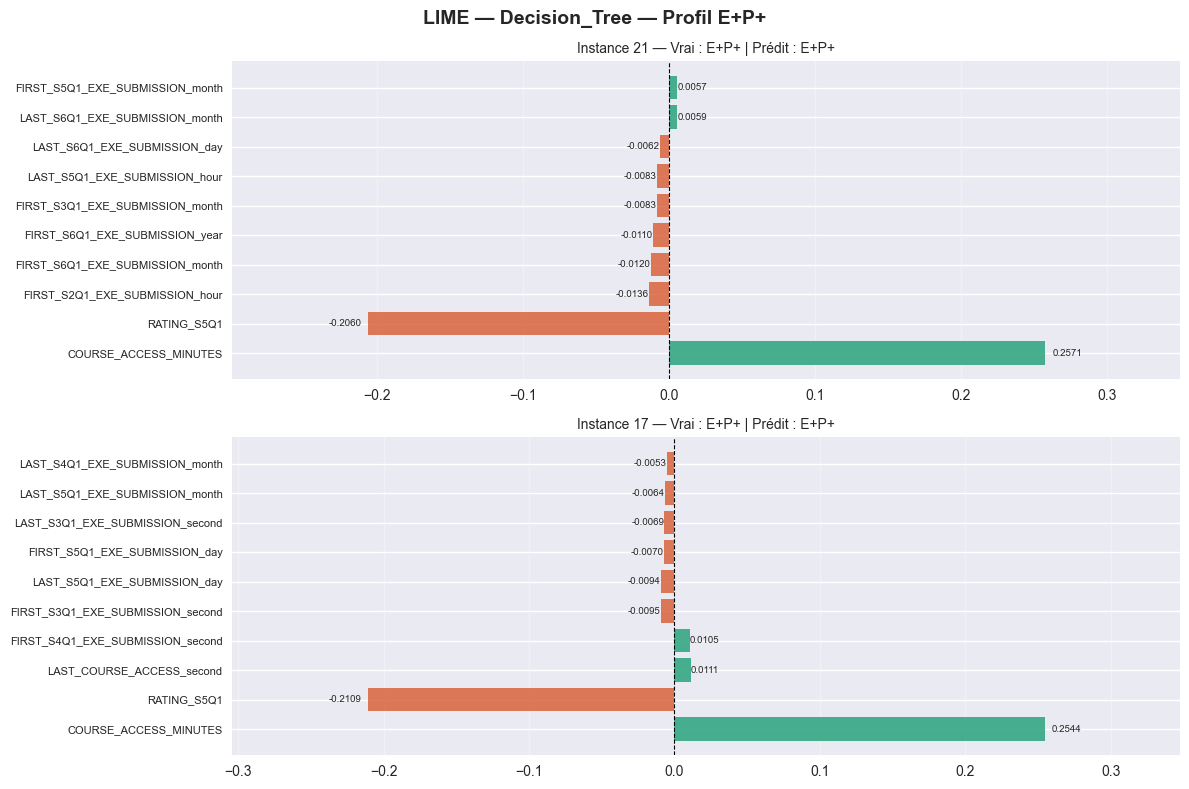

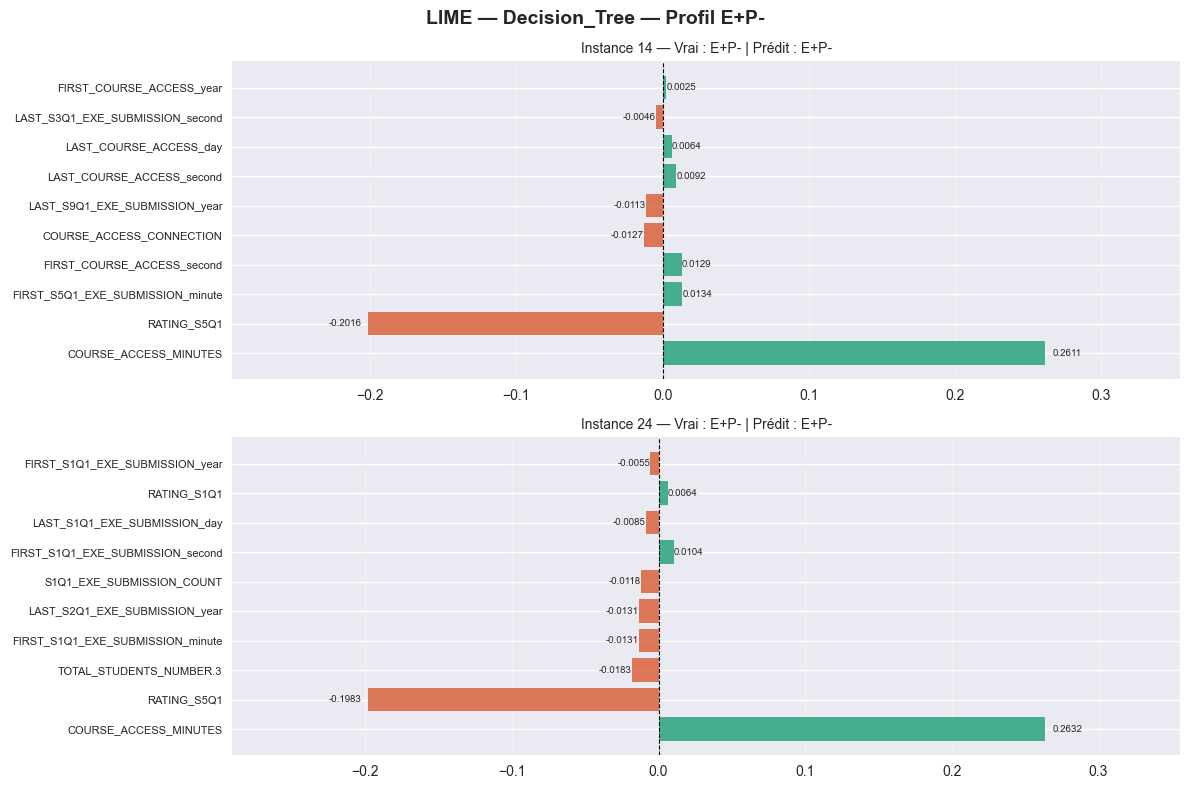

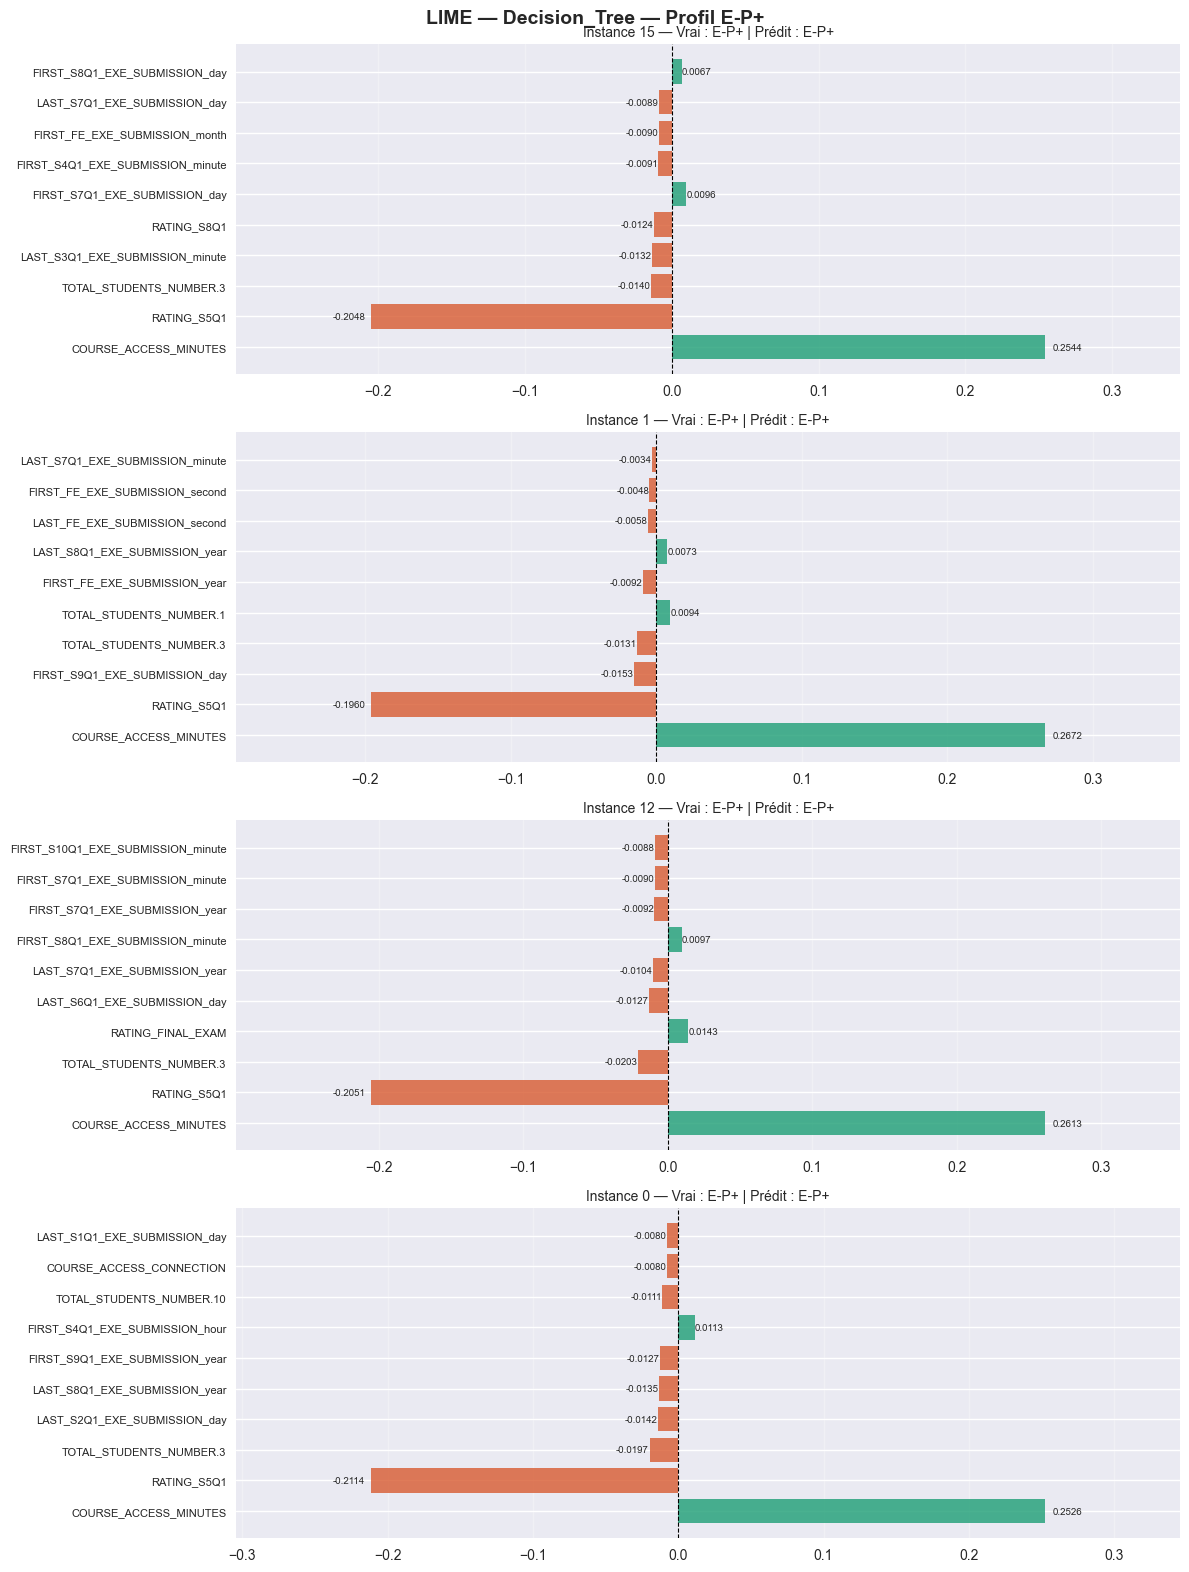

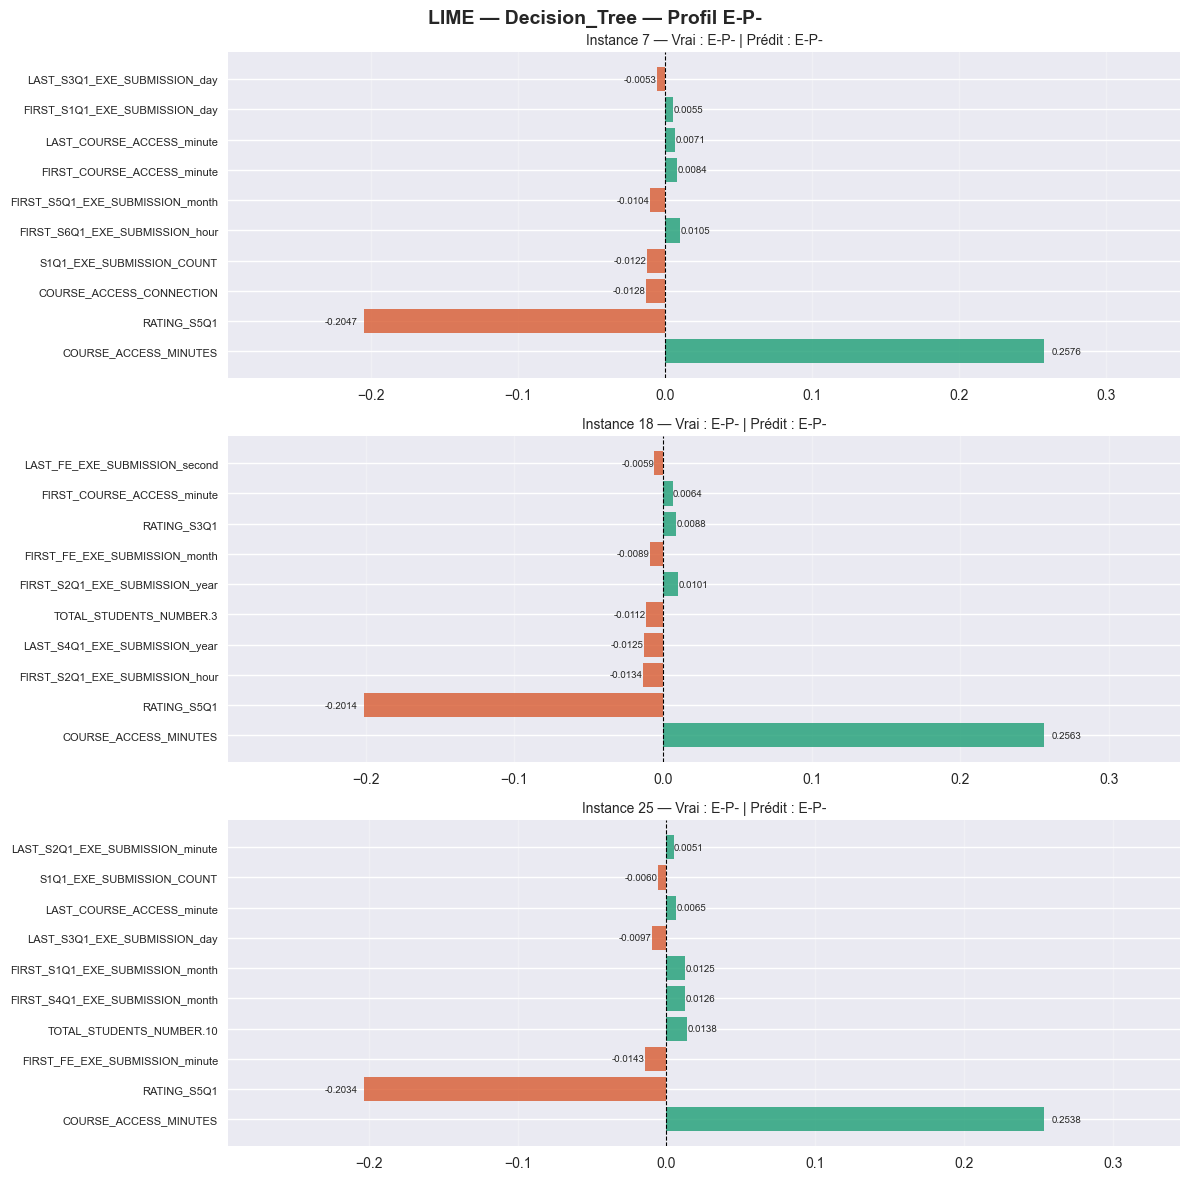

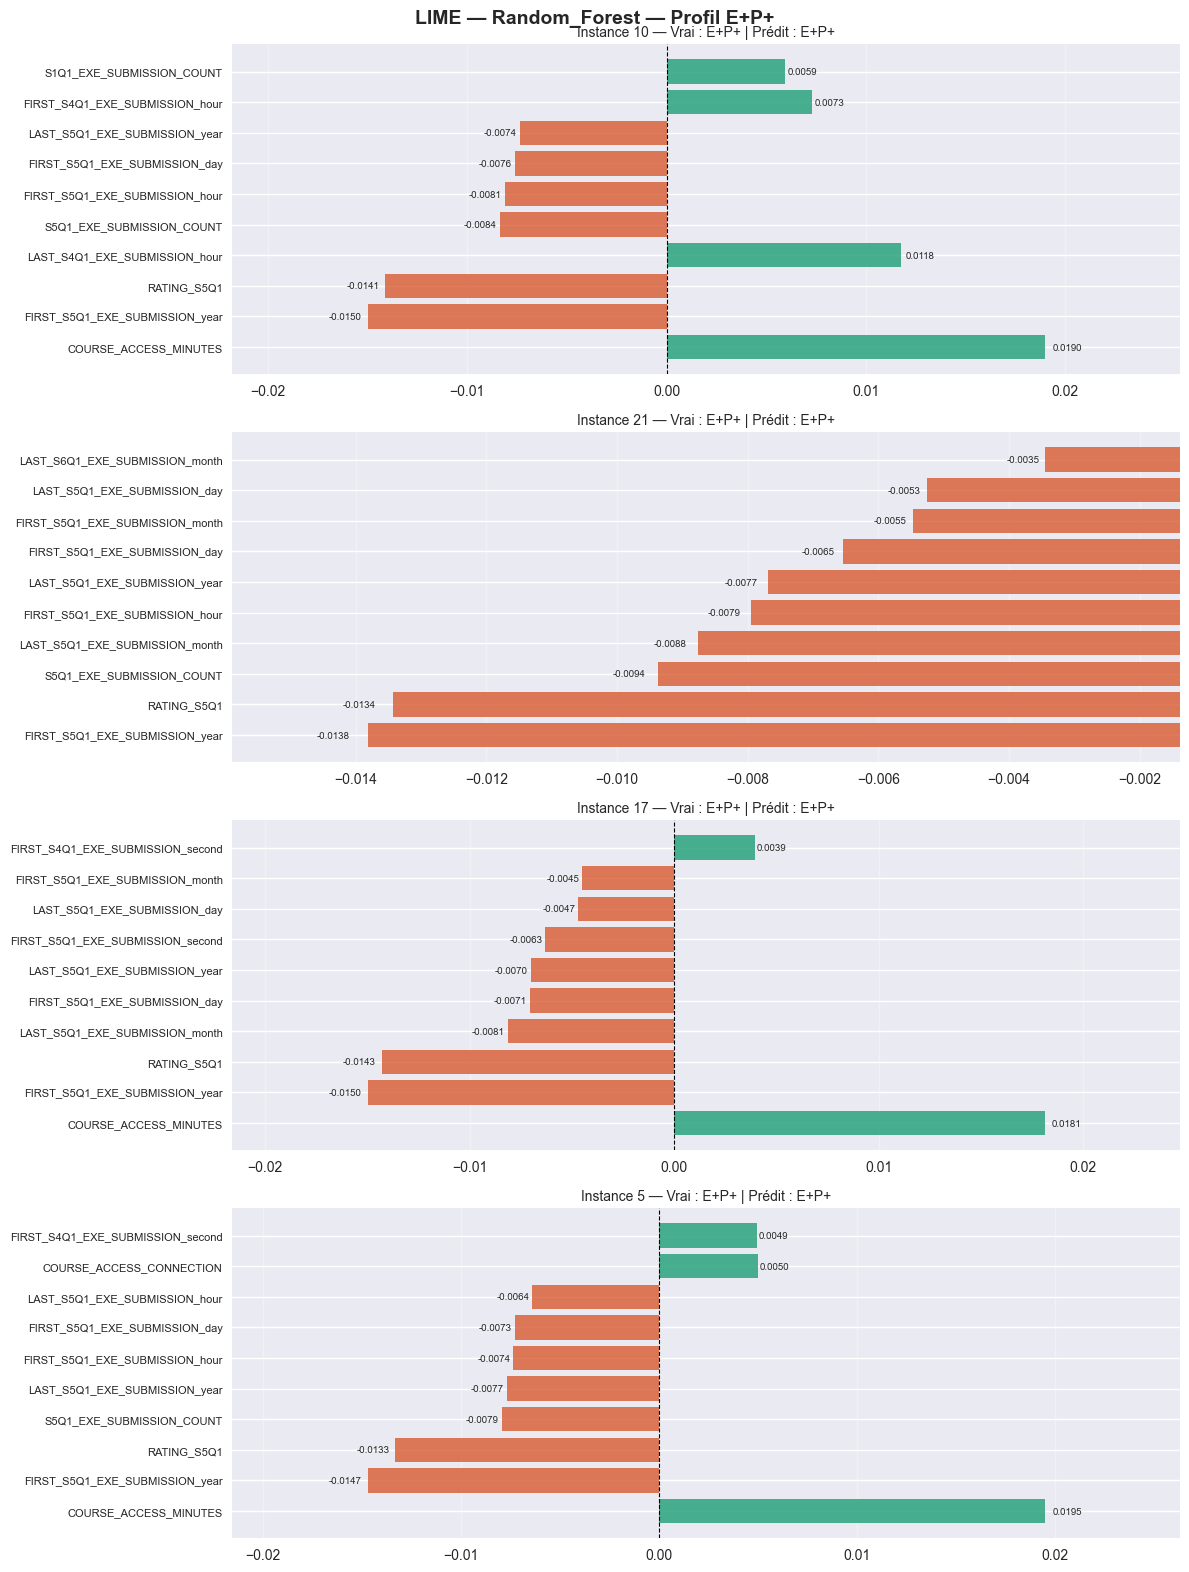

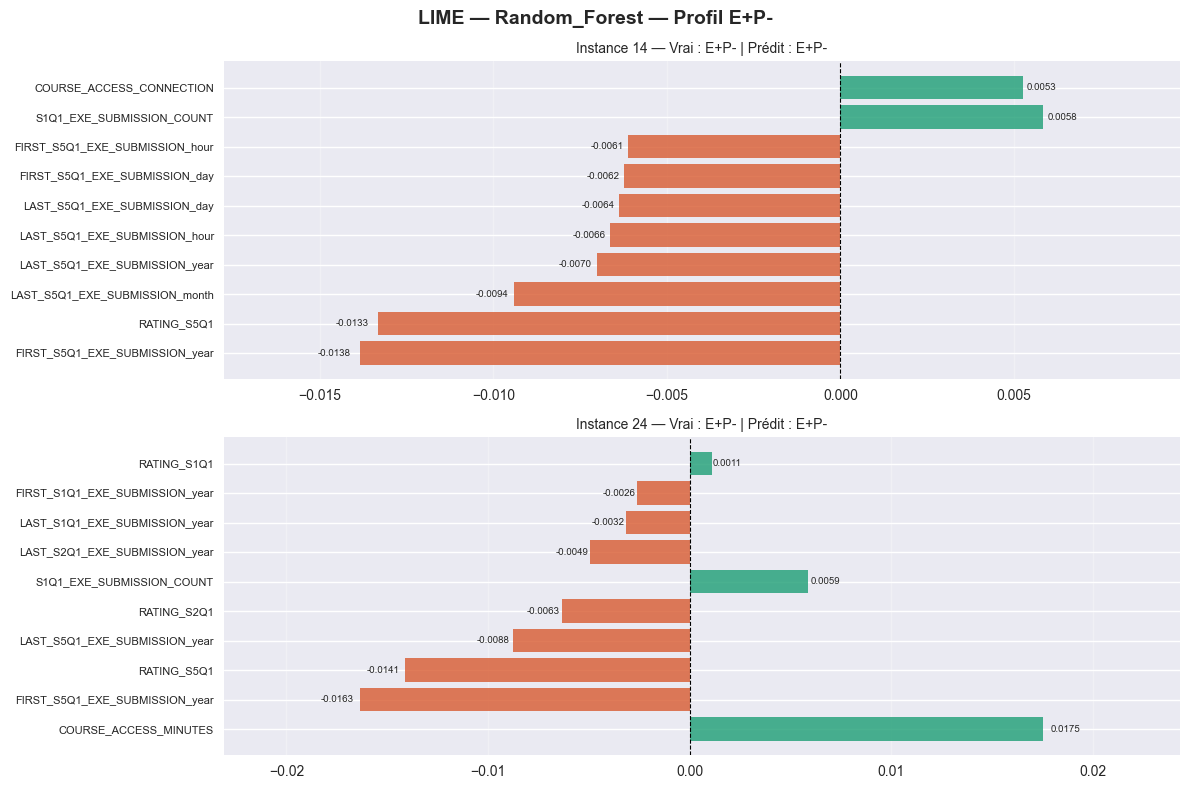

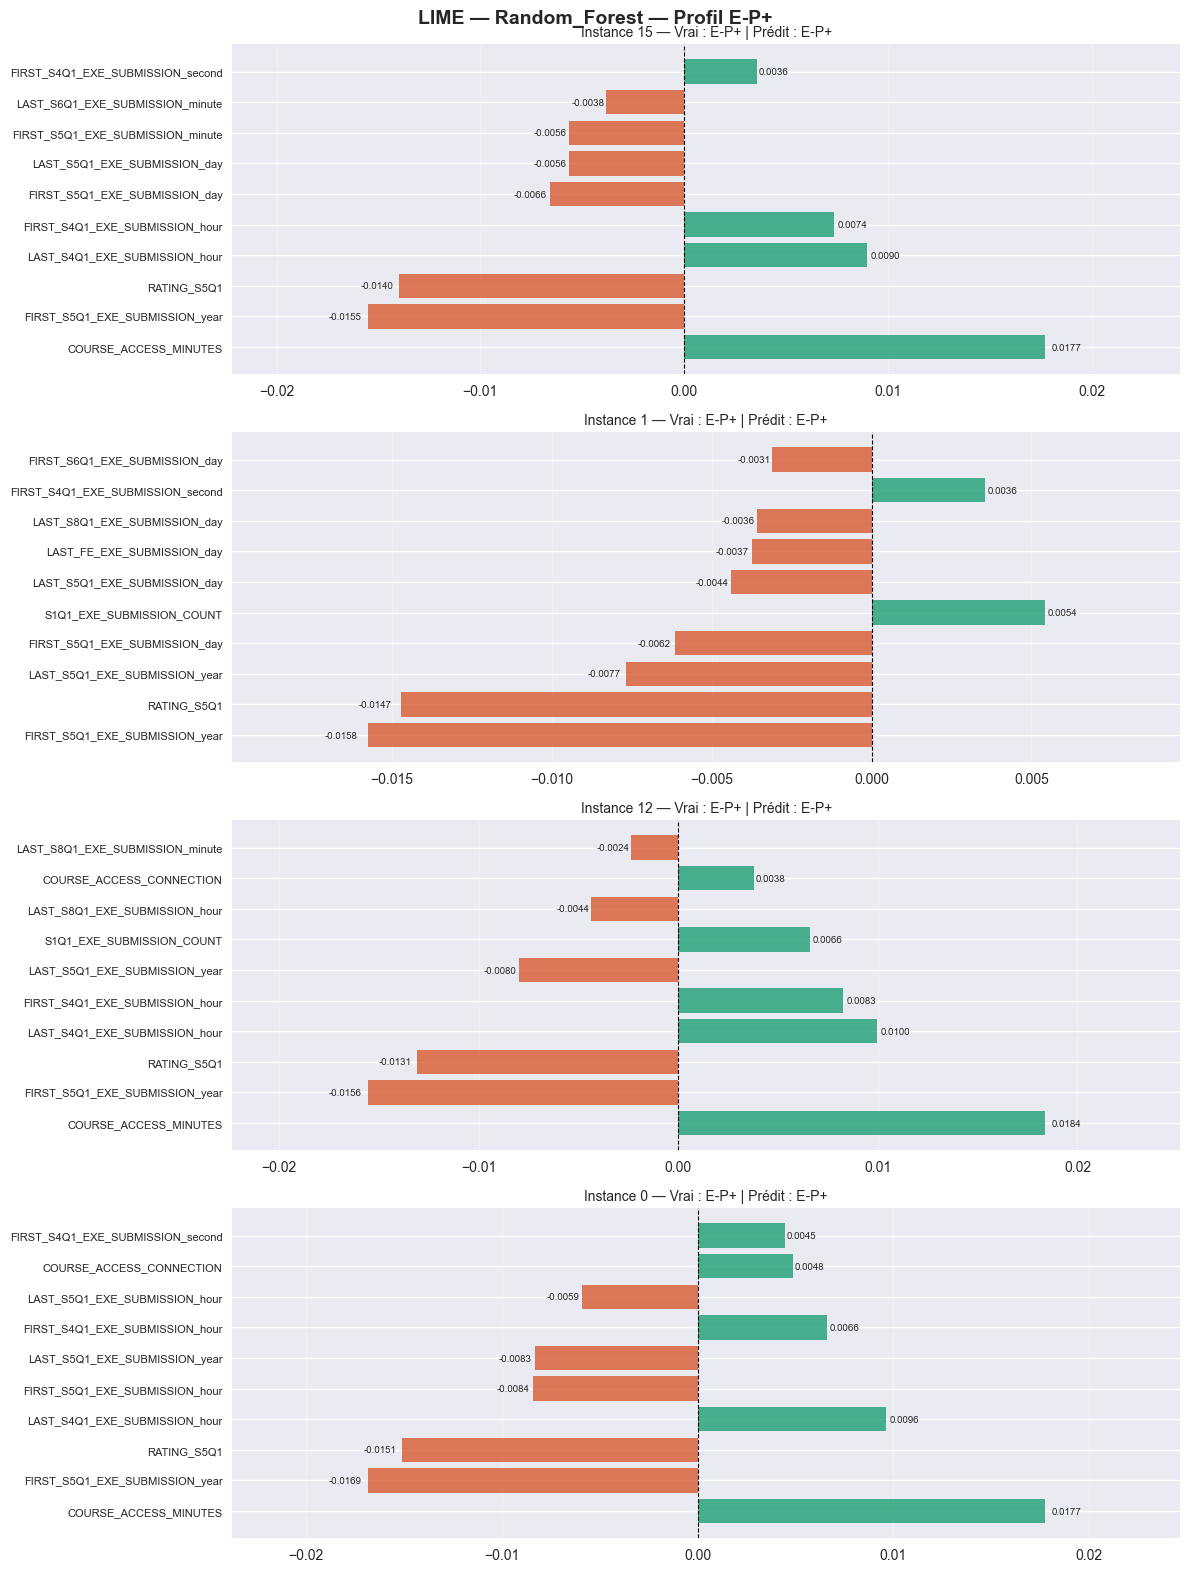

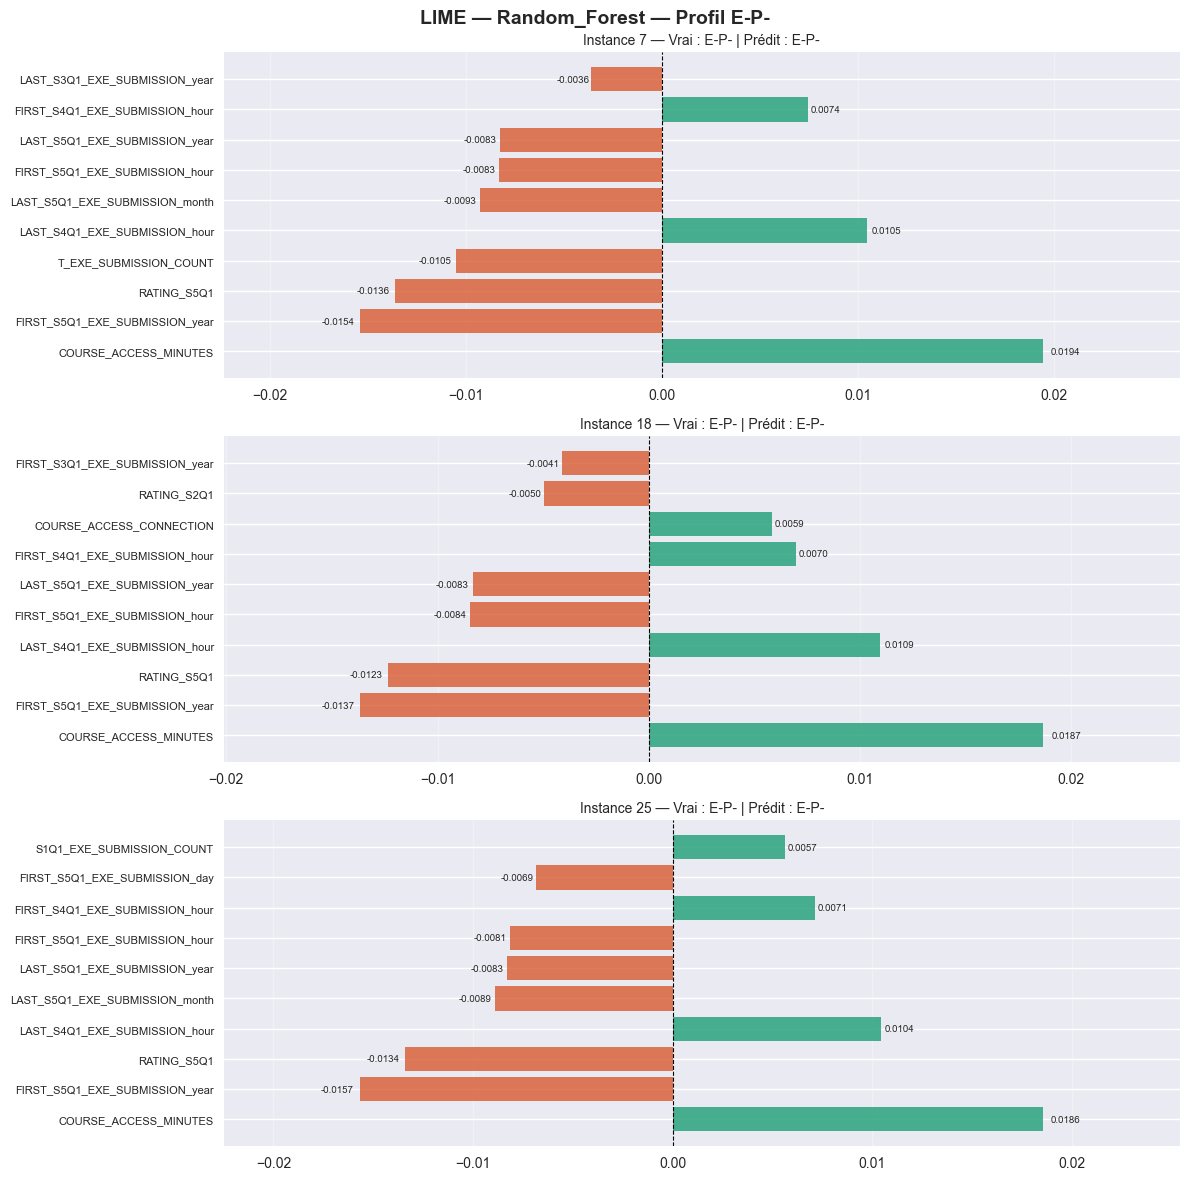

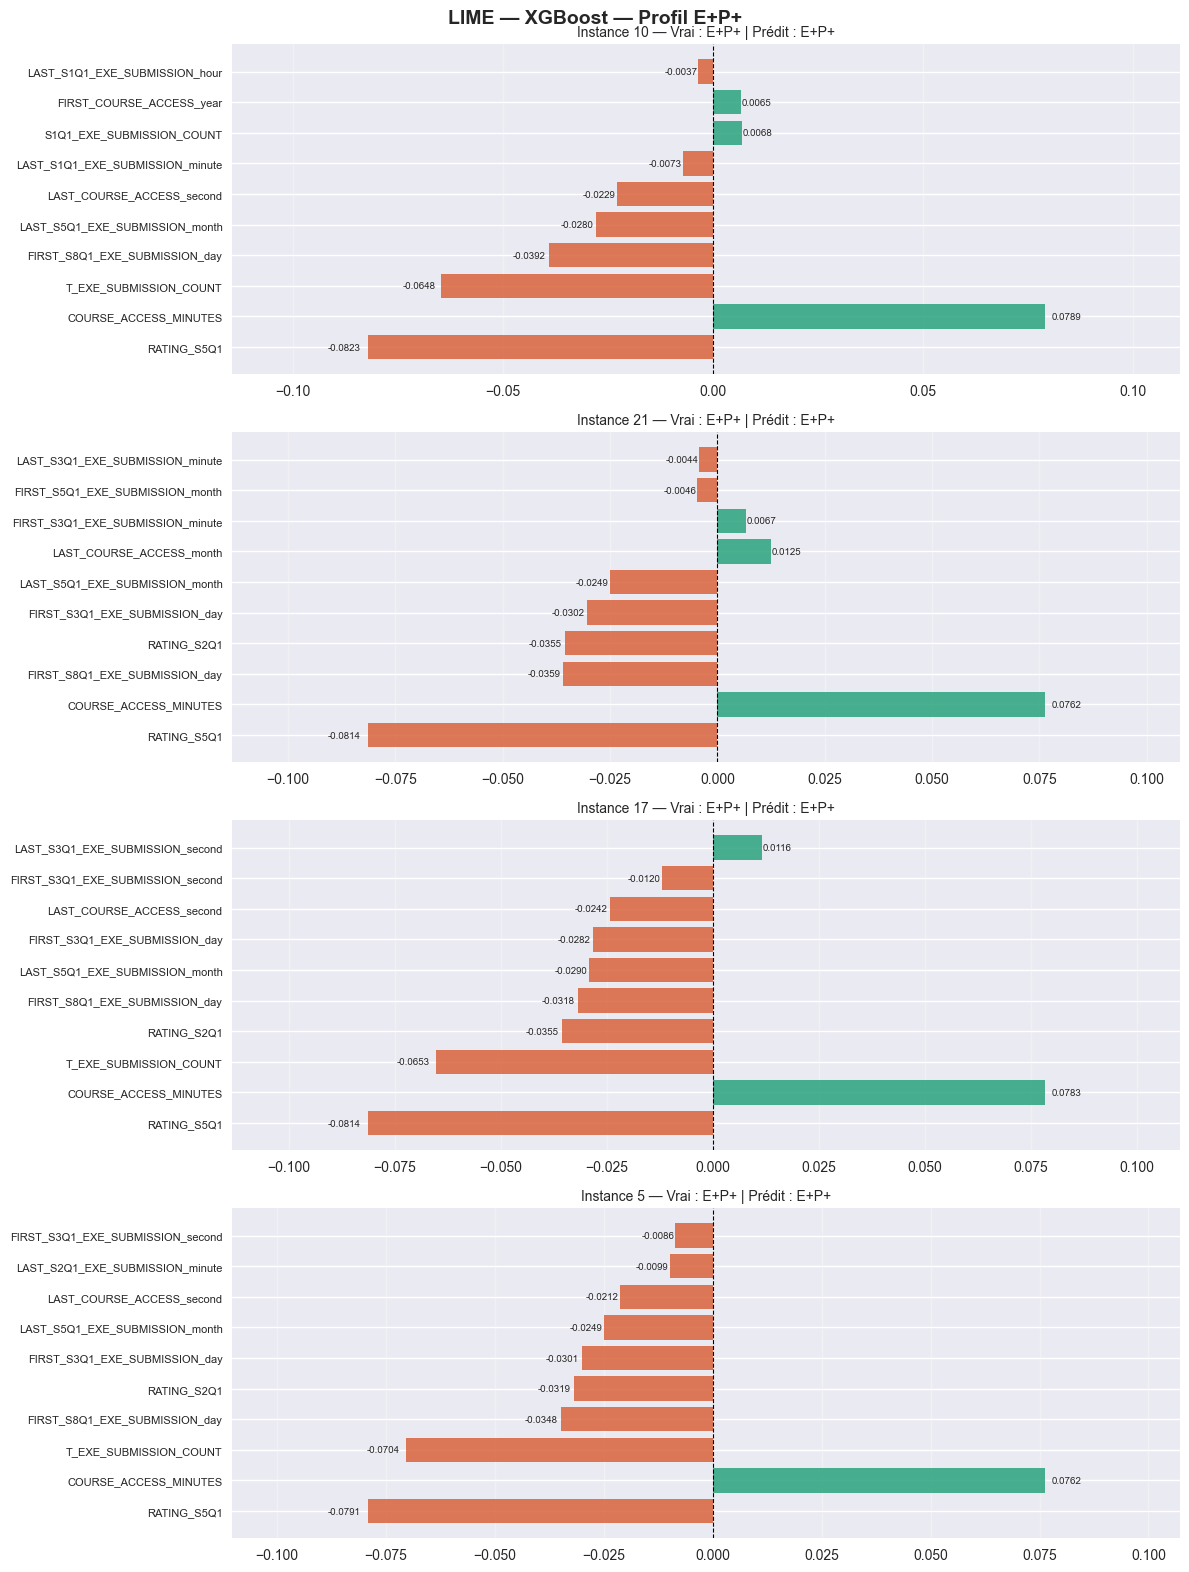

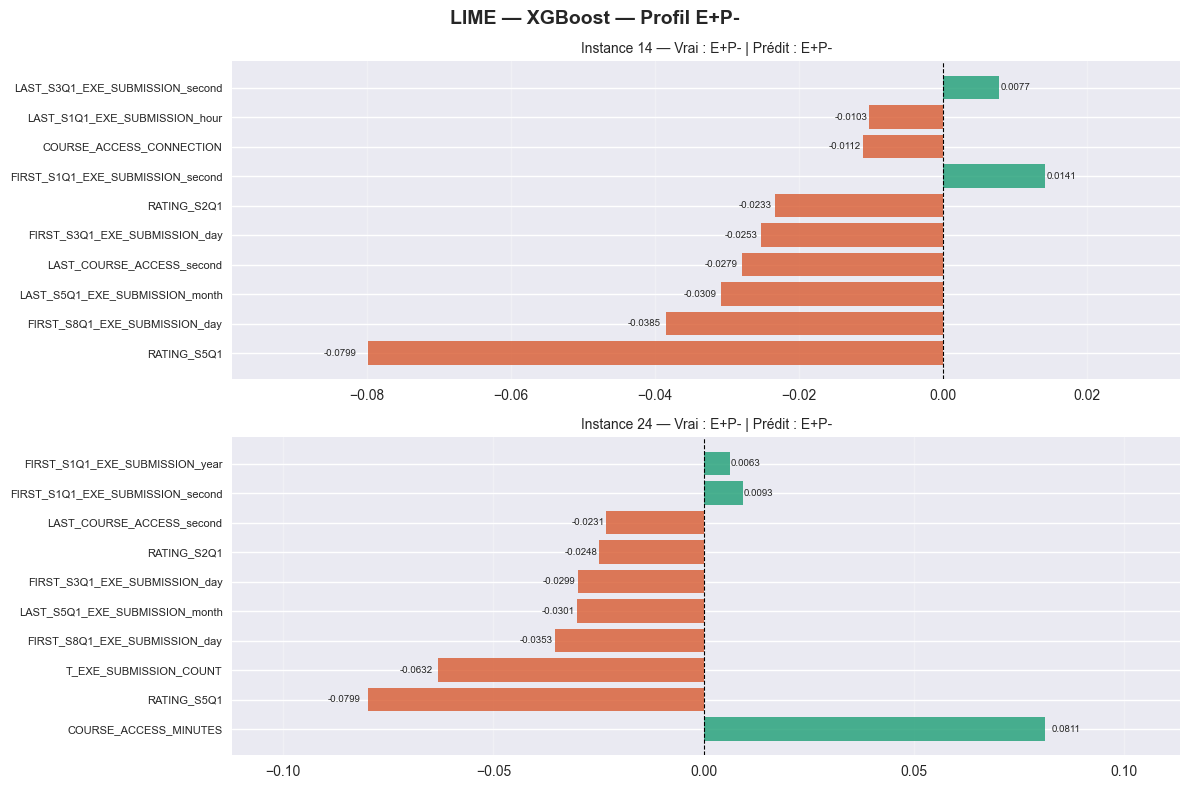

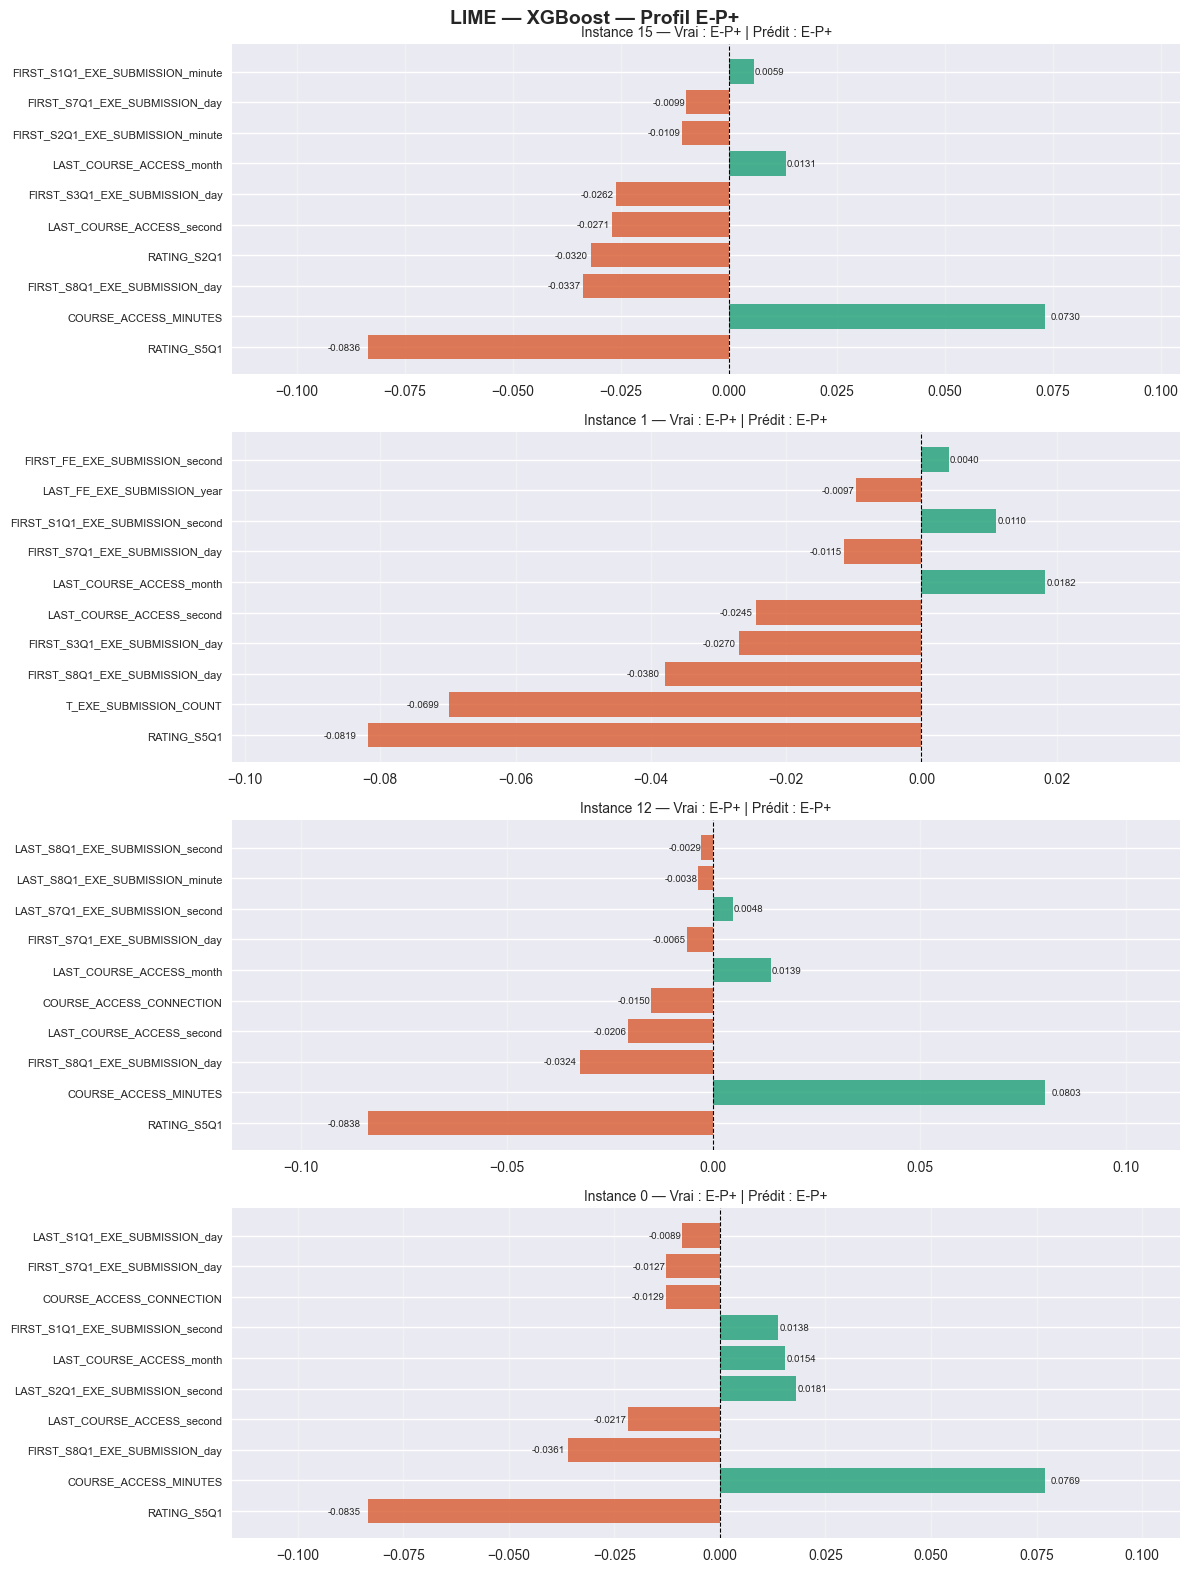

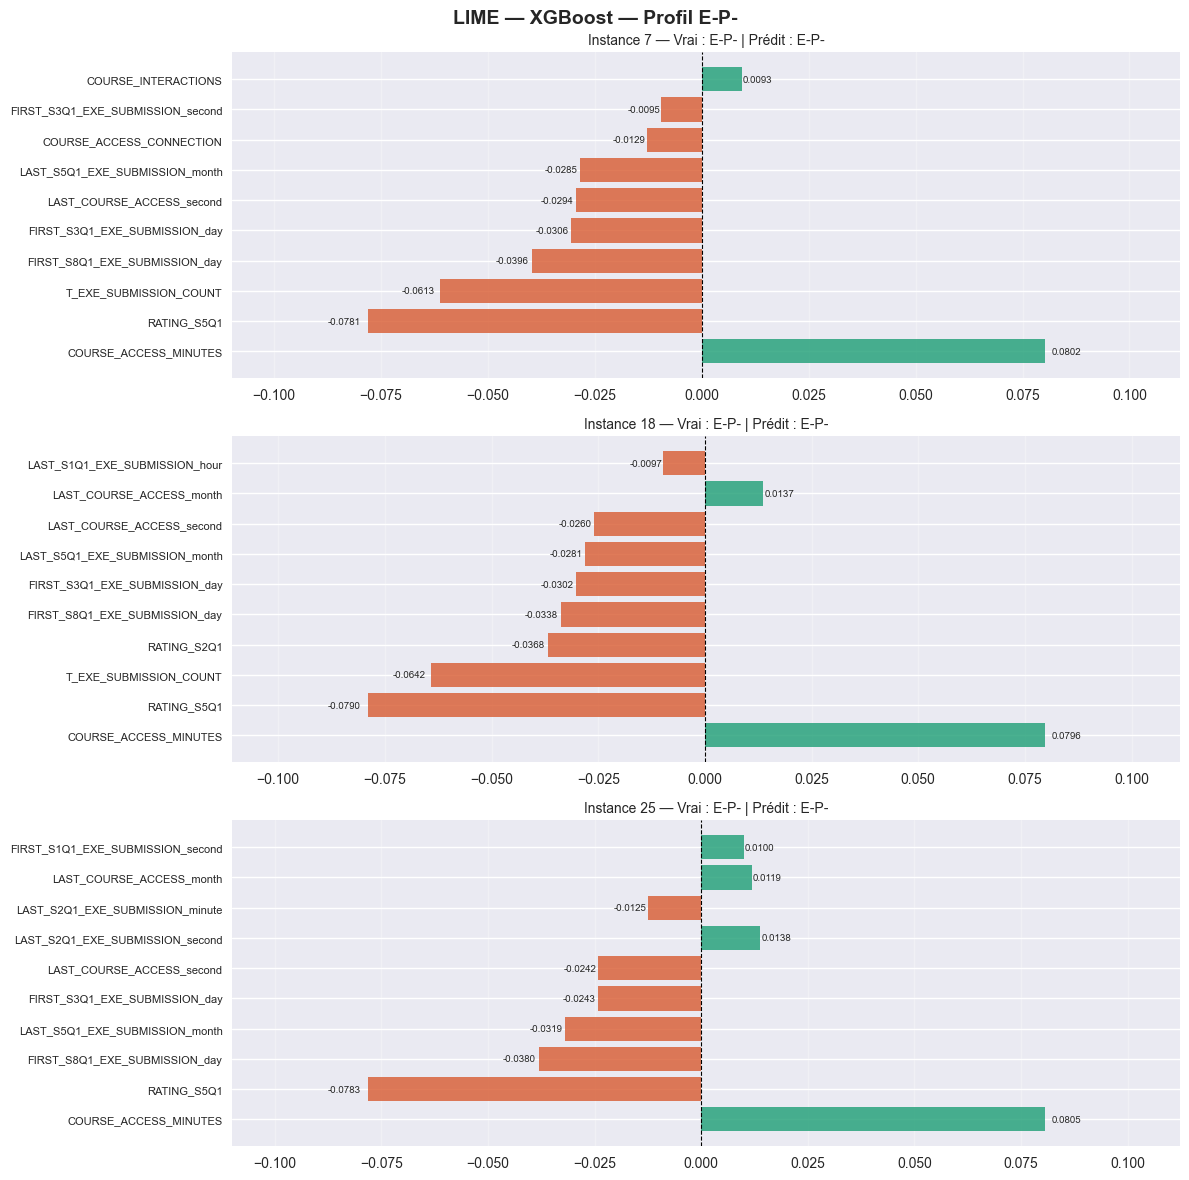

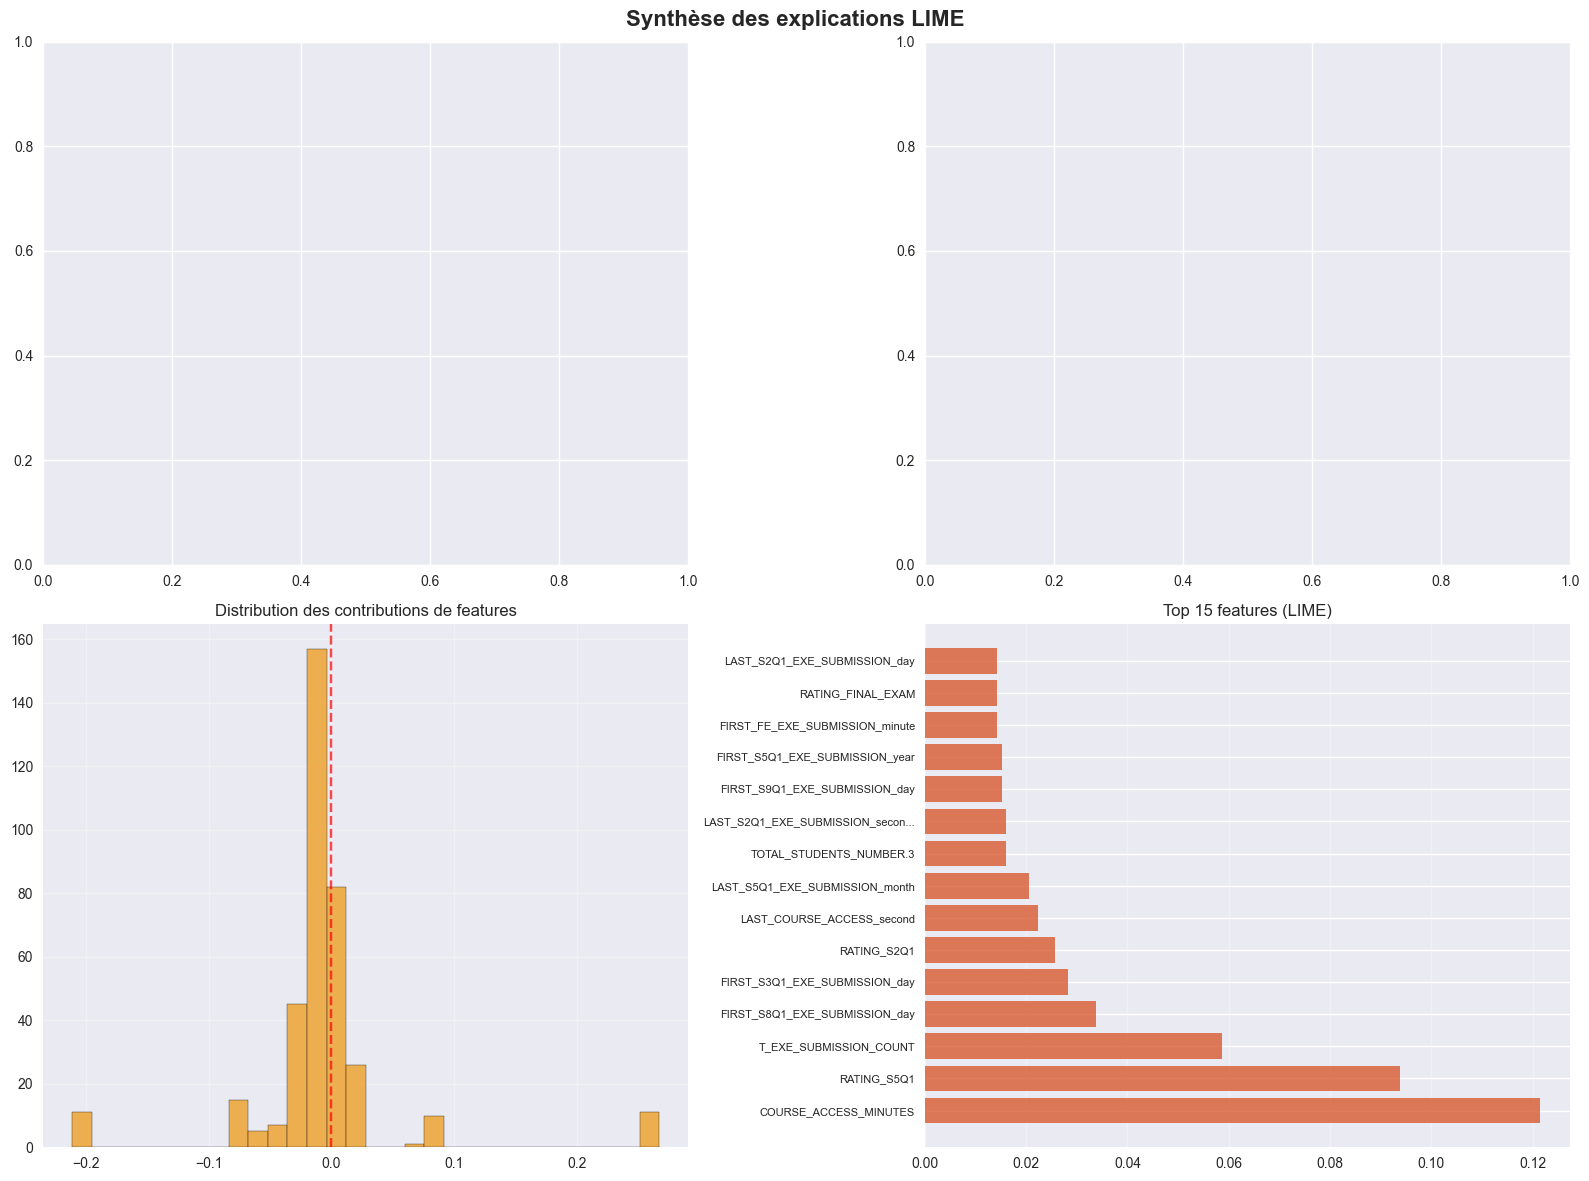


 ÉVALUATION QUALITÉ DES EXPLICATIONS LIME

  Decision_Tree
    [E+P+] instance 10 : Fidélité=0.000  Stabilité=0.352
    [E+P+] instance 21 : Fidélité=0.000  Stabilité=0.369
    [E+P-] instance 14 : Fidélité=0.000  Stabilité=0.398
    [E+P-] instance 24 : Fidélité=0.000  Stabilité=0.396
    [E-P+] instance 15 : Fidélité=0.000  Stabilité=0.324
    [E-P+] instance 1 : Fidélité=0.000  Stabilité=0.342
    [E-P-] instance 7 : Fidélité=0.000  Stabilité=0.367
    [E-P-] instance 18 : Fidélité=0.000  Stabilité=0.372

  Random_Forest
    [E+P+] instance 10 : Fidélité=0.000  Stabilité=0.806
    [E+P+] instance 21 : Fidélité=0.003  Stabilité=0.862
    [E+P-] instance 14 : Fidélité=0.083  Stabilité=0.861
    [E+P-] instance 24 : Fidélité=0.179  Stabilité=0.647
    [E-P+] instance 15 : Fidélité=0.000  Stabilité=0.855
    [E-P+] instance 1 : Fidélité=0.112  Stabilité=0.660
    [E-P-] instance 7 : Fidélité=0.000  Stabilité=0.665
    [E-P-] instance 18 : Fidélité=0.000  Stabilité=0.713

  XGBoost
    

In [23]:
lime_eval = LIMEEvaluator(evaluator)
lime_eval.run()